In [2]:
import yfinance as yf
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping
from prophet import Prophet
import itertools
import seaborn as sns
import time
import re
import string
import chardet
import html

C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_a = pd.read_excel('AMZN_dati_storici.xlsx')
# Converti la colonna 'Date' in formato datetime
df_a['Date'] = pd.to_datetime(df_a['Date'])
print(df_a.head())

        Date      Open      High       Low     Close      Volume  Dividends  \
0 1997-05-15  0.121875  0.125000  0.096354  0.097917  1443120000          0   
1 1997-05-16  0.098438  0.098958  0.085417  0.086458   294000000          0   
2 1997-05-19  0.088021  0.088542  0.081250  0.085417   122136000          0   
3 1997-05-20  0.086458  0.087500  0.081771  0.081771   109344000          0   
4 1997-05-21  0.081771  0.082292  0.068750  0.071354   377064000          0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  


In [4]:
#attività su dividendi e stock_split
# Crea copie temporanee per dividendi e stock split
dividendi = df_a[df_a['Dividends'] != 0].copy()
stock_split = df_a[df_a['Stock Splits'] != 0].copy()

# Visualizza le date e i valori di dividendi e stock split
print("Date dei dividendi:")
print(dividendi[['Date', 'Dividends']])

print("\nDate degli stock split:")
print(stock_split[['Date', 'Stock Splits']])

Date dei dividendi:
Empty DataFrame
Columns: [Date, Dividends]
Index: []

Date degli stock split:
           Date  Stock Splits
263  1998-06-02             2
413  1999-01-05             3
580  1999-09-02             2
6306 2022-06-06            20


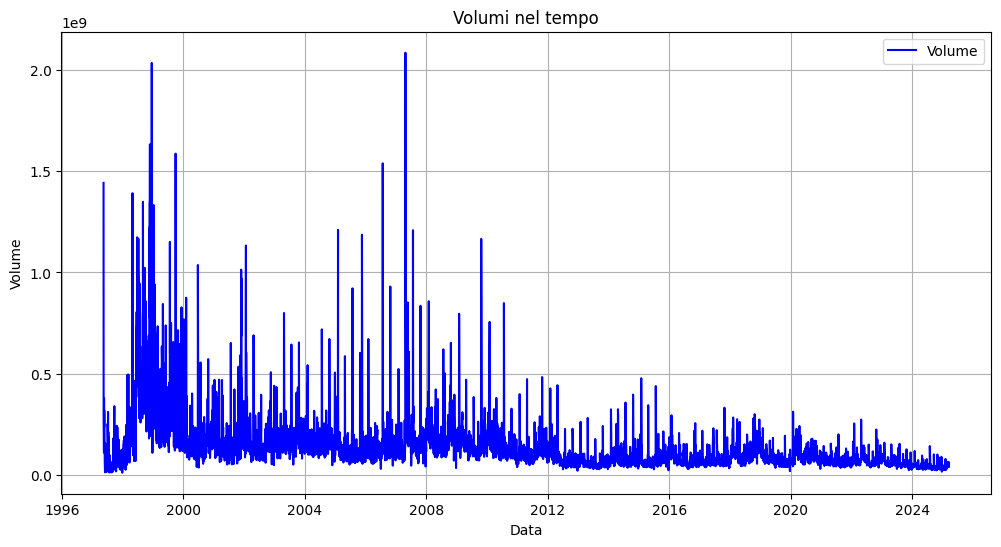

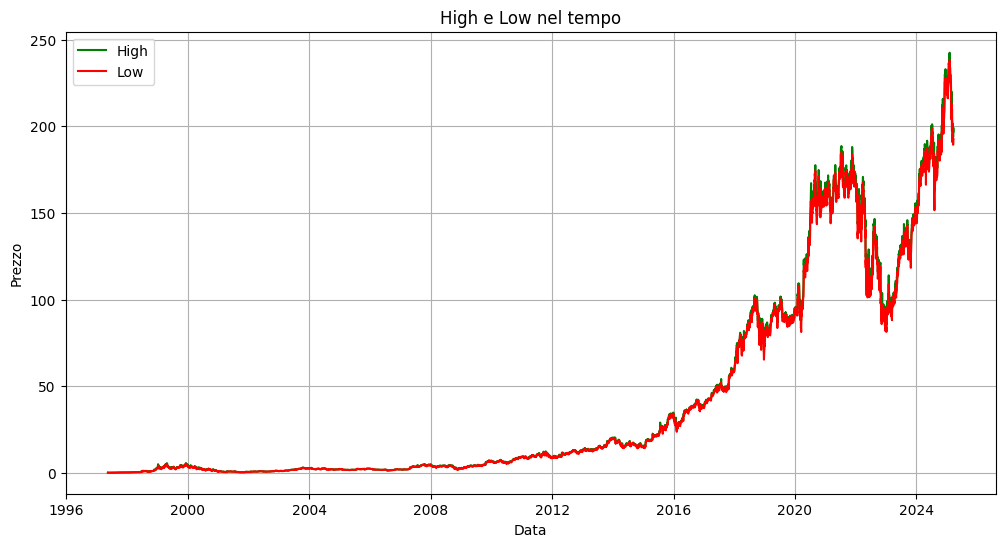

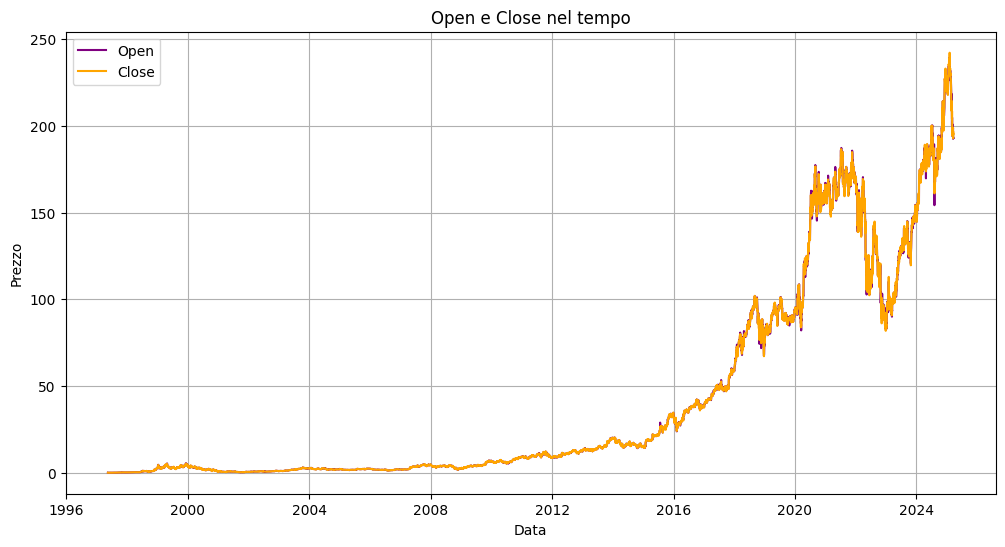

In [5]:
# 1. Grafico dei volumi
plt.figure(figsize=(12, 6))
plt.plot(df_a['Date'], df_a['Volume'], label='Volume', color='blue')
plt.title('Volumi nel tempo')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

# 2. Grafico High e Low
plt.figure(figsize=(12, 6))
plt.plot(df_a['Date'], df_a['High'], label='High', color='green')
plt.plot(df_a['Date'], df_a['Low'], label='Low', color='red')
plt.title('High e Low nel tempo')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

# 3. Grafico Open e Close
plt.figure(figsize=(12, 6))
plt.plot(df_a['Date'], df_a['Open'], label='Open', color='purple')
plt.plot(df_a['Date'], df_a['Close'], label='Close', color='orange')
plt.title('Open e Close nel tempo')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

In [6]:
#trasformazione logaritmica
# Crea una copia di df_a
df_a_log = df_a.copy()

# Colonne numeriche da trasformare (escludi 'Date' e colonne non numeriche)
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Applica la trasformazione logaritmica alle colonne numeriche
for col in numeric_cols:
    # Aggiungi una piccola costante per evitare logaritmi di zero o valori negativi
    df_a_log[col] = np.log(df_a_log[col])
# Visualizza le prime righe di df_a_log
print(df_a_log.head())

        Date      Open      High       Low     Close     Volume  Dividends  \
0 1997-05-15 -2.104759 -2.079442 -2.339726 -2.323635  21.090073          0   
1 1997-05-16 -2.318328 -2.313060 -2.460210 -2.448097  19.499090          0   
2 1997-05-19 -2.430180 -2.424278 -2.510224 -2.460210  18.620646          0   
3 1997-05-20 -2.448097 -2.436117 -2.503833 -2.503833  18.510009          0   
4 1997-05-21 -2.503833 -2.497481 -2.677279 -2.640102  19.747925          0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  


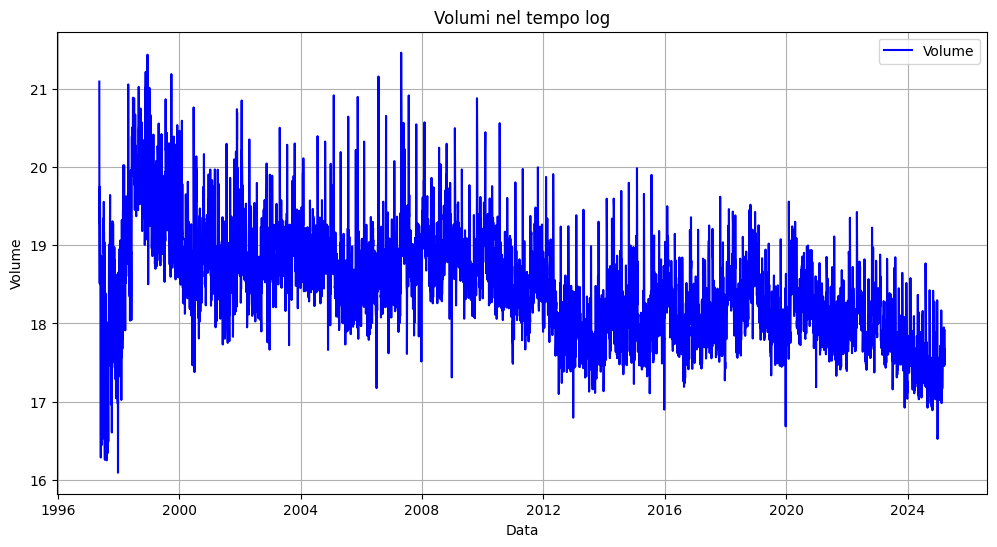

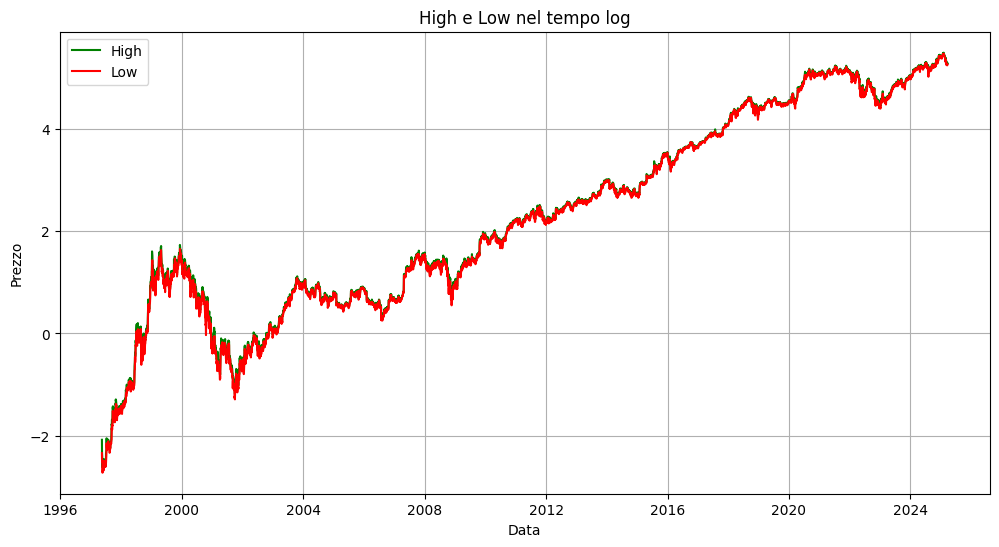

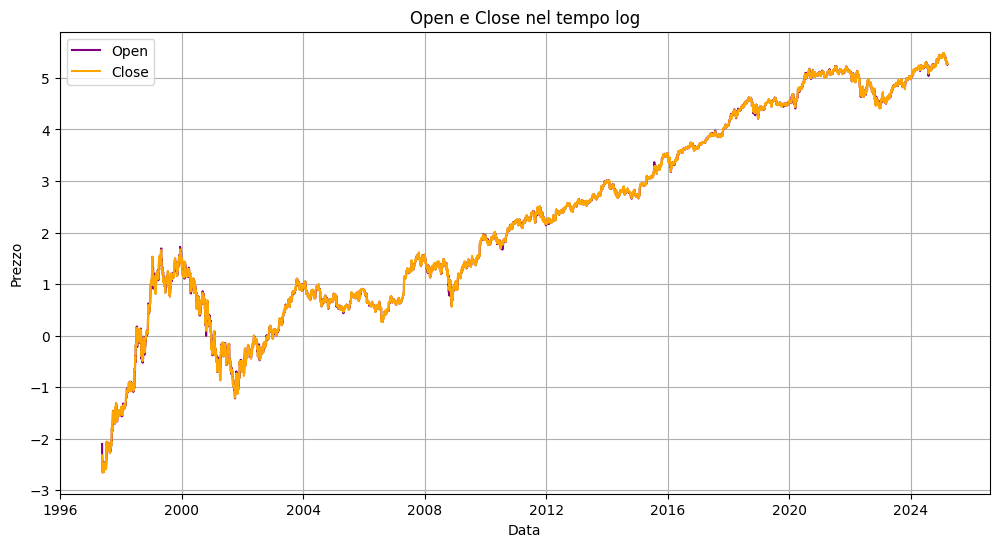

In [7]:
# 1. Grafico dei volumi
plt.figure(figsize=(12, 6))
plt.plot(df_a_log['Date'], df_a_log['Volume'], label='Volume', color='blue')
plt.title('Volumi nel tempo log')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

# 2. Grafico High e Low
plt.figure(figsize=(12, 6))
plt.plot(df_a_log['Date'], df_a_log['High'], label='High', color='green')
plt.plot(df_a_log['Date'], df_a_log['Low'], label='Low', color='red')
plt.title('High e Low nel tempo log')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

# 3. Grafico Open e Close
plt.figure(figsize=(12, 6))
plt.plot(df_a_log['Date'], df_a_log['Open'], label='Open', color='purple')
plt.plot(df_a_log['Date'], df_a_log['Close'], label='Close', color='orange')
plt.title('Open e Close nel tempo log')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

       Open      High       Low     Close       Date
0       NaN       NaN       NaN       NaN 1997-05-15
1 -0.192304 -0.208336 -0.113508 -0.117028 1997-05-16
2 -0.105823 -0.105257 -0.048784 -0.012040 1997-05-19
3 -0.017757 -0.011768  0.006412 -0.042685 1997-05-20
4 -0.054211 -0.059520 -0.159237 -0.127392 1997-05-21


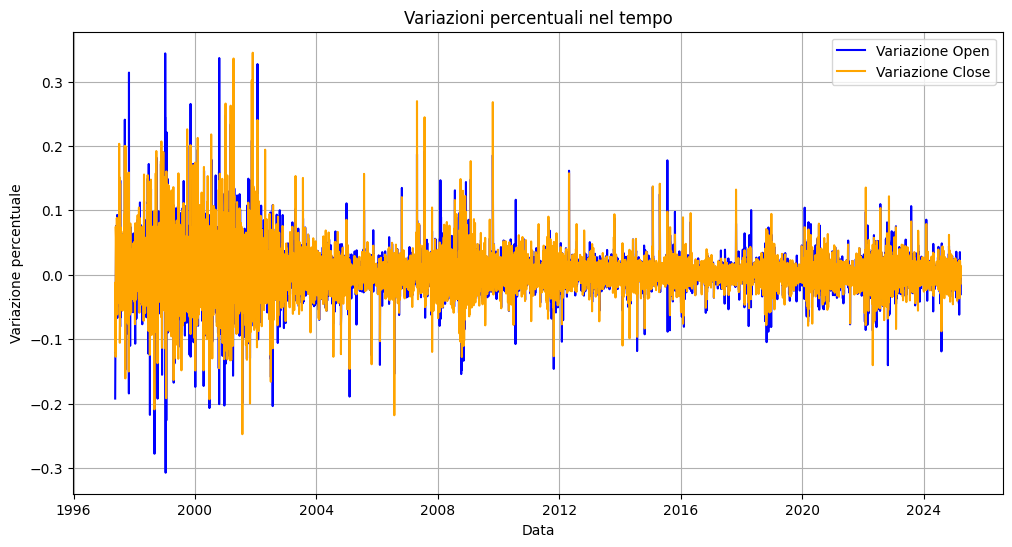

In [8]:
# Calcola le variazioni percentuali sui dati originali
variations_a = df_a[['Open', 'High', 'Low', 'Close']].pct_change()

# Aggiungi la colonna 'Date' al DataFrame delle variazioni
variations_a['Date'] = df_a['Date']

# Visualizza le prime righe del DataFrame delle variazioni
print(variations_a.head())

# Plot delle variazioni
plt.figure(figsize=(12, 6))
plt.plot(variations_a['Date'], variations_a['Open'], label='Variazione Open', color='blue')
plt.plot(variations_a['Date'], variations_a['Close'], label='Variazione Close', color='orange')
plt.title('Variazioni percentuali nel tempo')
plt.xlabel('Data')
plt.ylabel('Variazione percentuale')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
#dati originali
# Esegui il test ADF
lista= ["Open", "Close", "Volume"]
for i in lista:
    adf_test = adfuller(df_a[i])

    # Estrai i risultati
    statistic = adf_test[0]
    pvalue = adf_test[1]
    critical_values = adf_test[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: 0.6862246635561783
P-value: 0.9895589116253457
Valori critici: {'1%': np.float64(-3.431288013847613), '5%': np.float64(-2.8619545265178346), '10%': np.float64(-2.5669906485204703)}
non stazionario
ADF test Close
Statistica ADF: 0.9319848340429384
P-value: 0.9934938575907837
Valori critici: {'1%': np.float64(-3.431288283027058), '5%': np.float64(-2.861954645454677), '10%': np.float64(-2.5669907118326596)}
non stazionario
ADF test Volume
Statistica ADF: -5.0555761227285165
P-value: 1.7208160916960253e-05
Valori critici: {'1%': np.float64(-3.431288148418027), '5%': np.float64(-2.861954585977726), '10%': np.float64(-2.566990680172024)}
stazionario


In [10]:
#dati log
# Esegui il test ADF
lista= ["Open", "Close", "Volume"]
for i in lista:
    adf_test_log = adfuller(df_a_log[i])

    # Estrai i risultati
    statistic = adf_test_log[0]
    pvalue = adf_test_log[1]
    critical_values = adf_test_log[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: -2.0806272723734582
P-value: 0.252375480397656
Valori critici: {'1%': np.float64(-3.431288283027058), '5%': np.float64(-2.861954645454677), '10%': np.float64(-2.5669907118326596)}
non stazionario
ADF test Close
Statistica ADF: -1.922786728531018
P-value: 0.32141860249098675
Valori critici: {'1%': np.float64(-3.431288283027058), '5%': np.float64(-2.861954645454677), '10%': np.float64(-2.5669907118326596)}
non stazionario
ADF test Volume
Statistica ADF: -3.8590722647727027
P-value: 0.0023575741113488215
Valori critici: {'1%': np.float64(-3.431288148418027), '5%': np.float64(-2.861954585977726), '10%': np.float64(-2.566990680172024)}
stazionario


In [11]:
# Applica la differenziazione
df_a_trasf = df_a_log.diff().dropna()
#ADF sui dati trasformati
for i in lista:
    adf_test_trasf = adfuller(df_a_trasf[i])

    # Estrai i risultati
    statistic = adf_test_trasf[0]
    pvalue = adf_test_trasf[1]
    critical_values = adf_test_trasf[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: -14.312623455016311
P-value: 1.1772727253414415e-26
Valori critici: {'1%': np.float64(-3.431288283027058), '5%': np.float64(-2.861954645454677), '10%': np.float64(-2.5669907118326596)}
stazionario
ADF test Close
Statistica ADF: -14.268800043285433
P-value: 1.385712981190102e-26
Valori critici: {'1%': np.float64(-3.431288283027058), '5%': np.float64(-2.861954645454677), '10%': np.float64(-2.5669907118326596)}
stazionario
ADF test Volume
Statistica ADF: -21.64706496620058
P-value: 0.0
Valori critici: {'1%': np.float64(-3.431288552361039), '5%': np.float64(-2.8619547644597905), '10%': np.float64(-2.5669907751811927)}
stazionario


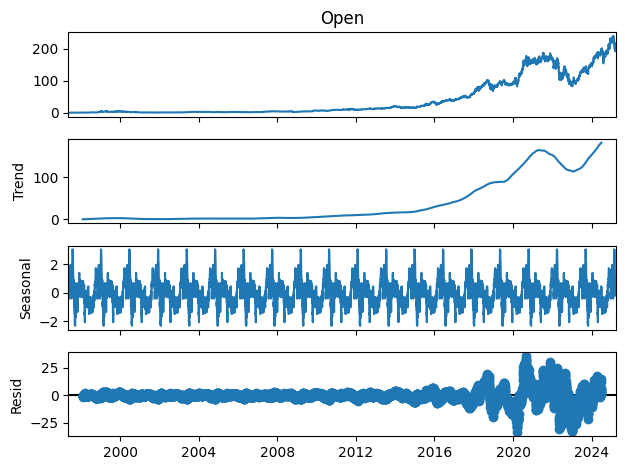

Statistica ADF sui residui: -7.246103647628801
P-value: 1.8305499622369752e-10
Valori critici: {'1%': np.float64(-3.4313399882072266), '5%': np.float64(-2.8619774911706215), '10%': np.float64(-2.5670028730464285)}
stazionario


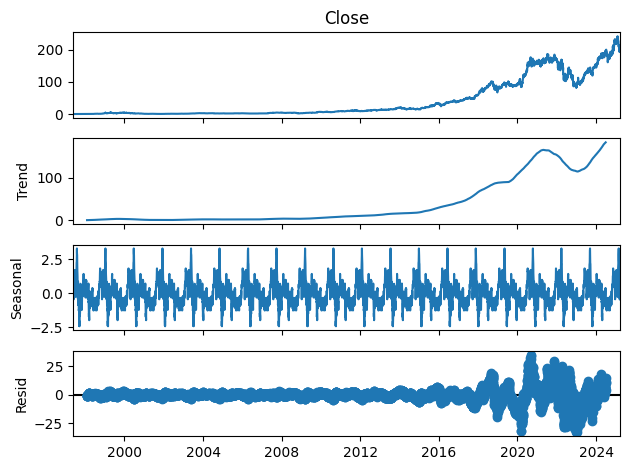

Statistica ADF sui residui: -7.3935291128278235
P-value: 7.886373462335798e-11
Valori critici: {'1%': np.float64(-3.4313399882072266), '5%': np.float64(-2.8619774911706215), '10%': np.float64(-2.5670028730464285)}
stazionario


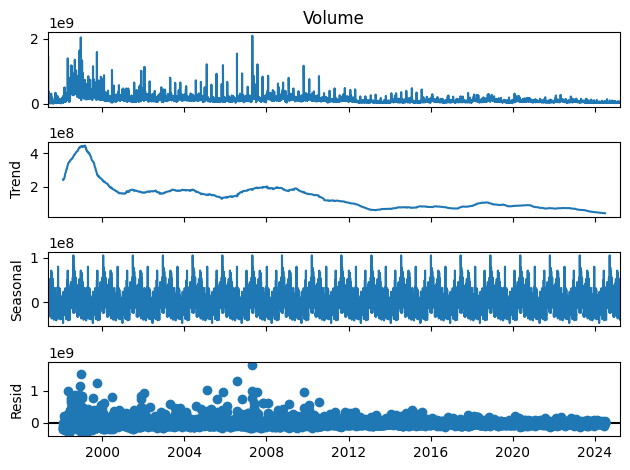

Statistica ADF sui residui: -12.483726568756925
P-value: 3.051152917201964e-23
Valori critici: {'1%': np.float64(-3.4313387906586015), '5%': np.float64(-2.8619769620433004), '10%': np.float64(-2.567002591381013)}
stazionario


In [12]:
# Crea una copia di df_a
df_a_decomp = df_a.copy()

# Imposta la colonna 'Date' come indice
df_a_decomp.set_index('Date', inplace=True)

for i in lista:
    data = df_a_decomp[i]
    
    # Applica la decomposizione stagionale
    decomposition = seasonal_decompose(data, model='additive', period=365)  # Modifica il periodo se necessario
    
    # Visualizza la decomposizione
    decomposition.plot()
    plt.show()
    
    # Estrai i residui
    resid = decomposition.resid.dropna()
    
    # Esegui il test ADF sui residui
    adf_test = adfuller(resid)
    
    # Estrai i risultati
    statistic = adf_test[0]
    pvalue = adf_test[1]
    critical_values = adf_test[4]
    
    # Stampa i risultati
    print("Statistica ADF sui residui:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

In [13]:
#Metodi di Previsione con dataset stazionario
#preso i valori di close con operazione diff. e trasf. log. mentre i valori volume gli originali perhché già stazionari
data_a = pd.DataFrame({
    'Close': df_a_trasf['Close'],
    'Open': df_a_trasf['Open']
})
# Dividi i dati in train e test set
train_a, test_a = train_test_split(data_a, test_size=0.2, shuffle=False)

# Visualizza le dimensioni dei set
print("Dimensione train_a:", train_a.shape)
print("Dimensione test_a:", test_a.shape)

# Visualizza le prime righe dei set
print("\nTrain_a:")
print(train_a.head())
print(train_a.tail())

print("\nTest_a:")
print(test_a.head())
print(test_a.tail())

Dimensione train_a: (5604, 2)
Dimensione test_a: (1402, 2)

Train_a:
      Close      Open
1 -0.124461 -0.213569
2 -0.012114 -0.111851
3 -0.043623 -0.017917
4 -0.136269 -0.055736
5 -0.022134 -0.128994
         Close      Open
5600  0.009219  0.006098
5601  0.013052  0.013952
5602 -0.008149 -0.001971
5603  0.012227  0.002691
5604 -0.010407  0.004721

Test_a:
         Close      Open
5605 -0.030974 -0.019316
5606  0.010942 -0.014675
5607 -0.003988  0.004979
5608  0.001373 -0.011743
5609  0.012477  0.015828
         Close      Open
7002 -0.011227  0.006866
7003 -0.015030 -0.031948
7004  0.014008  0.004457
7005 -0.003022 -0.001604
7006  0.006442 -0.000881


In [14]:
#verifica di valori 0 o infinito
print(data_a['Close'][data_a['Close'].isna()])
print(data_a['Close'][np.isinf(data_a['Close'])])  
print(data_a['Open'][data_a['Open'].isna()])
print(data_a['Open'][np.isinf(data_a['Open'])])

# Gestisci il valore NaN (esempio: imputazione con la media)
data_a['Close'] = data_a['Close'].fillna(data_a['Close'].mean())

# Verifica la correzione
print(data_a['Close'].isna().sum())
print(data_a['Close'].isin([np.inf, -np.inf]).sum())
print(data_a['Open'].isna().sum())
print(data_a['Open'].isin([np.inf, -np.inf]).sum())

Series([], Name: Close, dtype: float64)
Series([], Name: Close, dtype: float64)
Series([], Name: Open, dtype: float64)
Series([], Name: Open, dtype: float64)
0
0
0
0


In [15]:
lista1= ['Close', 'Open']
for i in lista1:
    adf_test_data_a = adfuller(data_a[i])
    
    # Estrai i risultati
    statistic = adf_test_data_a[0]
    pvalue = adf_test_data_a[1]
    critical_values = adf_test_data_a[4]
    
    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Close
Statistica ADF: -14.268800043285433
P-value: 1.385712981190102e-26
Valori critici: {'1%': np.float64(-3.431288283027058), '5%': np.float64(-2.861954645454677), '10%': np.float64(-2.5669907118326596)}
stazionario
ADF test Open
Statistica ADF: -14.312623455016311
P-value: 1.1772727253414415e-26
Valori critici: {'1%': np.float64(-3.431288283027058), '5%': np.float64(-2.861954645454677), '10%': np.float64(-2.5669907118326596)}
stazionario


Close


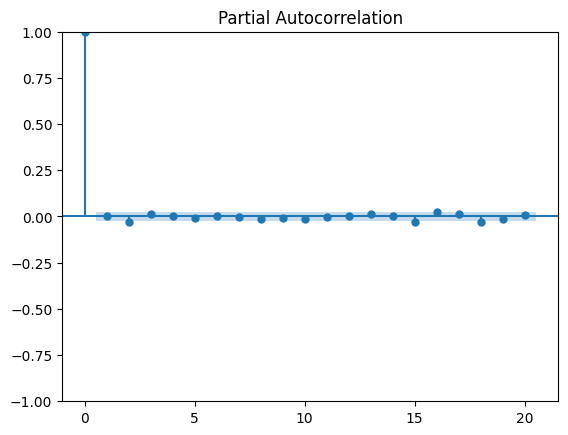

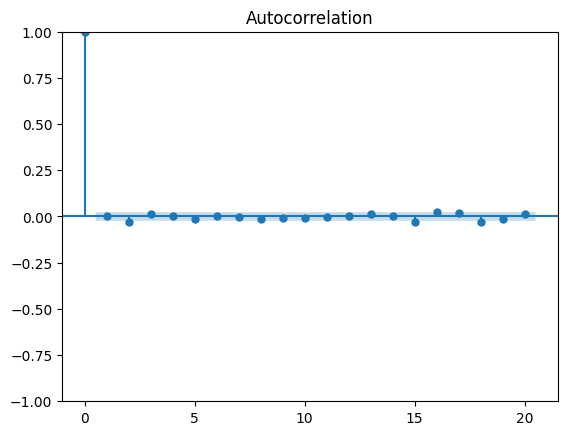

Open


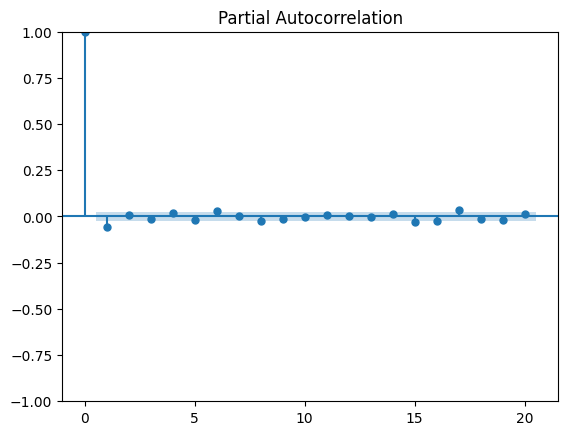

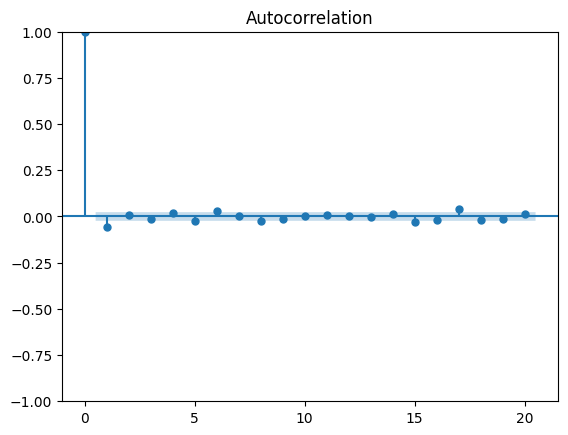

In [16]:
for campo in data_a:
    print (campo)
    plot_pacf(data_a[campo], lags=20)
    plt.show()
    plot_acf(data_a[campo], lags=20)
    plt.show()

In [17]:
def calcola_metriche(y_true, y_pred):
    # Rimuovi i valori NaN
    y_true = y_true.dropna()
    y_pred = y_pred.dropna()
    # Allinea gli indici per garantire che y_true e y_pred abbiano la stessa lunghezza
    y_true, y_pred = y_true.align(y_pred, join='inner')
    me = np.mean(y_pred - y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mpe = np.mean((y_true - y_pred) / y_true) * 100
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return me, rmse, mae, mpe, mape

In [18]:
def modello_arima(train,test,p,d,q):
    modello_arima = ARIMA(train, order=(p, d, q))
    risultati_arima = modello_arima.fit()
    # Effettua le previsioni sul set di train
    previsioni_train_arima = risultati_arima.predict(start=0, end=len(train) - 1)
    # Effettua le previsioni sul set di test
    previsioni_test_arima = risultati_arima.predict(start=len(train), end=len(train) + len(test) - 1)
    me_train, rmse_train, mae_train, mpe_train, mape_train = calcola_metriche(train, previsioni_train_arima)
    print('Valutazione train')
    print(f"ME: {me_train}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    me_test, rmse_test, mae_test, mpe_test, mape_test = calcola_metriche(test, previsioni_test_arima)
    print('Valutazione test')
    print(f"ME: {me_test}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")
    # Visualizza le previsioni rispetto ai dati reali
    plt.figure(figsize=(12, 6))
    plt.plot(train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(train.index, previsioni_train_arima, label='Previsioni Train', color='red')
    plt.plot(test.index, previsioni_test_arima, label='Previsioni Test', color='green')
    plt.legend()
    plt.title('Previsioni ARIMA')
    plt.show()
    return risultati_arima

C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Valutazione train
ME: -4.9068085585230506e-06, RMSE: 0.03717263314665555, MAE: 0.023532839731095986, MPE: nan, MAPE: inf
Valutazione test
ME: 0.0006635374195540372, RMSE: 0.02189750939692566, MAE: 0.01572762488904161, MPE: -inf, MAPE: inf


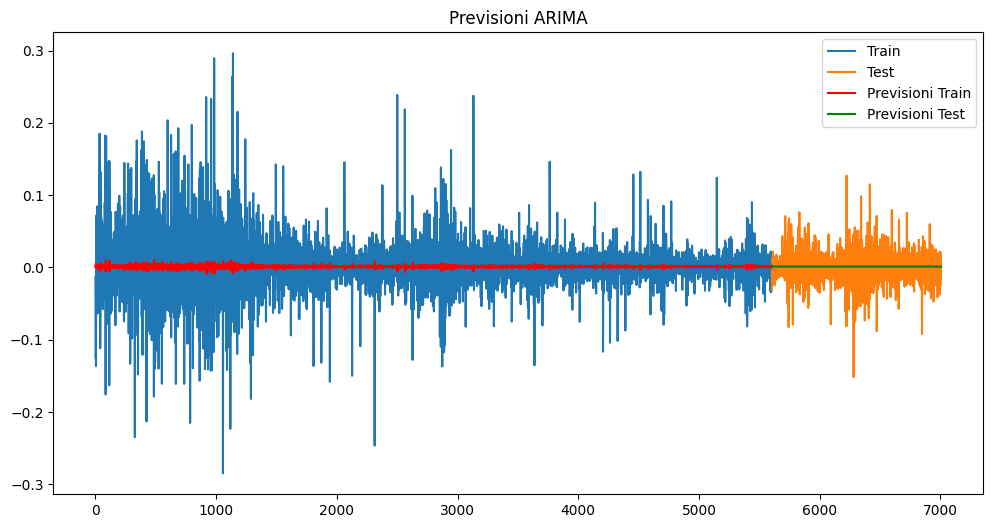

C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Valutazione train
ME: -3.619241366433745e-06, RMSE: 0.03873935894493131, MAE: 0.02409083857128751, MPE: nan, MAPE: inf
Valutazione test
ME: 0.0006440659291268518, RMSE: 0.02288802684218975, MAE: 0.016221805985676224, MPE: -inf, MAPE: inf


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


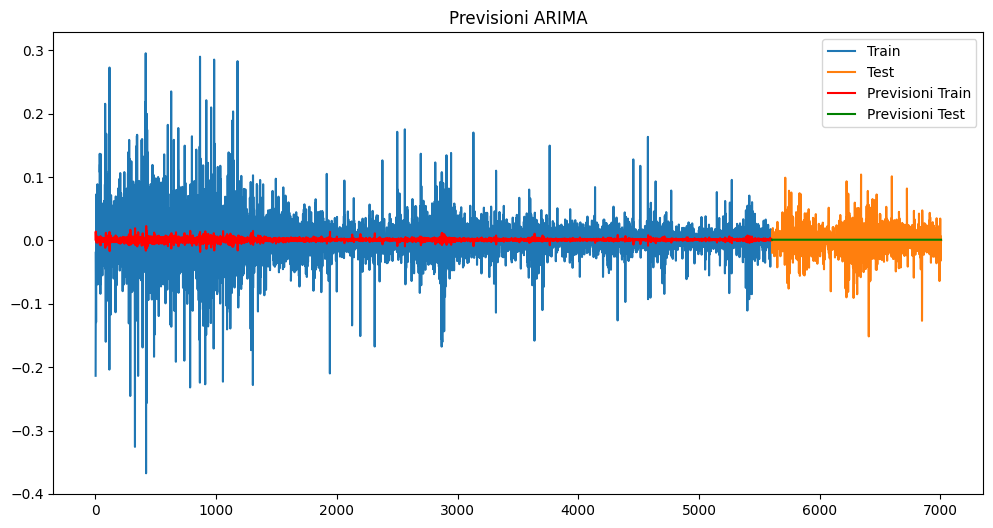

In [19]:
modello_arima(train_a['Close'], test_a['Close'], 4, 0, 4)
modello_arima(train_a['Open'], test_a['Open'], 2, 0, 1)

In [20]:
#arima iterativo
def modello_arima_iterativo(train, test, p_range, d_range, q_range):
    miglior_rmse = float('inf')
    miglior_modello = None
    migliori_parametri = None
    pdq = list(itertools.product(p_range, d_range, q_range))

    print(pdq)

    for param in pdq:
        rmse_test = None
        try:
            modello_arima = ARIMA(train, order=param)
            risultati_arima = modello_arima.fit()
            previsioni_test_arima = risultati_arima.predict(start=len(train), end=len(train) + len(test) - 1)
            rmse_test = mean_squared_error(test, previsioni_test_arima, squared=False)

            if rmse_test < miglior_rmse:
                miglior_rmse = rmse_test
                miglior_modello = risultati_arima
                migliori_parametri = param

        except:
            pass

        print(f"Parametri: {param}, RMSE: {rmse_test}")

    print(f"Migliori parametri: {migliori_parametri}")
    print(f"Miglior RMSE: {miglior_rmse}")

    # Visualizza le previsioni del miglior modello (se trovato)
    if miglior_modello is not None:
        previsioni_train_arima = miglior_modello.predict(start=0, end=len(train) - 1)
        previsioni_test_arima = miglior_modello.predict(start=len(train), end=len(train) + len(test) - 1)
    else:
        previsioni_train_arima = np.zeros(len(train)) # Inizializza con zeri
        previsioni_test_arima = np.zeros(len(test)) # Inizializza con zeri

    plt.figure(figsize=(12, 6))
    plt.plot(train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(train.index, previsioni_train_arima, label='Previsioni Train', color='red')
    plt.plot(test.index, previsioni_test_arima, label='Previsioni Test', color='green')
    plt.legend()
    plt.title('Previsioni ARIMA')
    plt.show()

    return miglior_modello

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3)]


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (0, 0, 0), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (0, 0, 1), RMSE: None


...

Parametri: (3, 2, 1), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported

Parametri: (3, 2, 2), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Parametri: (3, 2, 3), RMSE: None
Migliori parametri: None
Miglior RMSE: inf


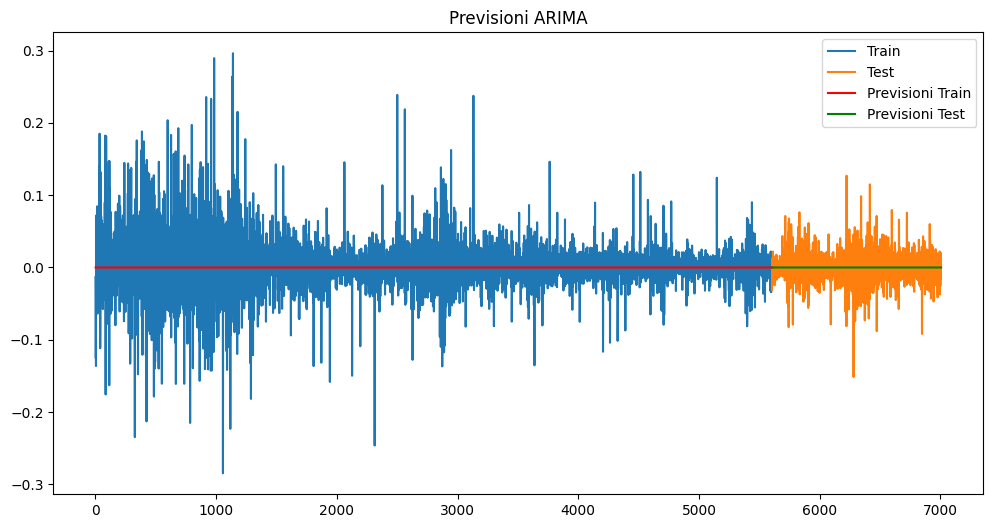

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3)]


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (0, 0, 0), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (0, 0, 1), RMSE: None


...

Parametri: (3, 2, 1), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (3, 2, 2), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Parametri: (3, 2, 3), RMSE: None
Migliori parametri: None
Miglior RMSE: inf


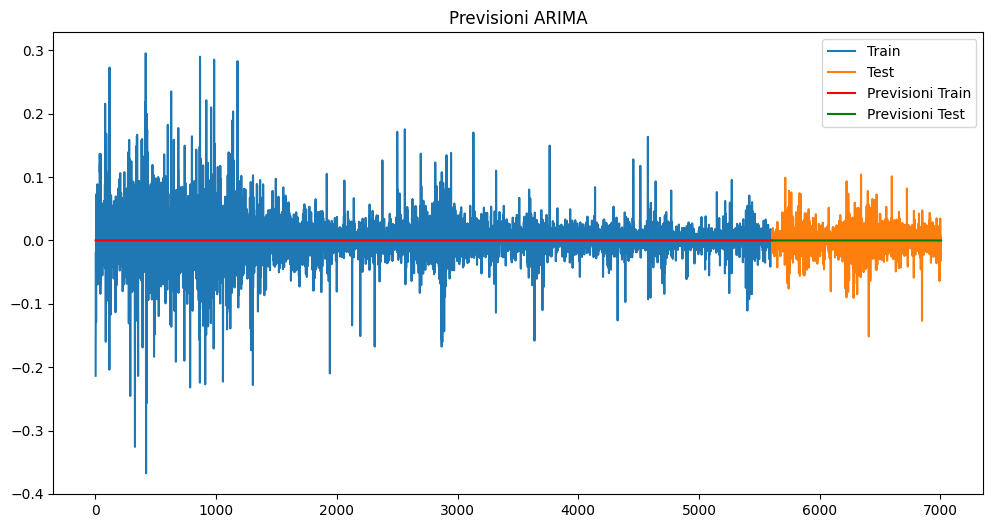

In [21]:
p_range = range(0, 4)
d_range = range(0, 3)
q_range = range(0, 4)

miglior_modello = modello_arima_iterativo(train_a['Close'], test_a['Close'], p_range, d_range, q_range)
miglior_modello = modello_arima_iterativo(train_a['Open'], test_a['Open'], p_range, d_range, q_range)

In [22]:
#Modello Prophet
#preparazione del dataset per prophet 
data_a_prophet = pd.DataFrame({
    'ds': df_a['Date'],
    'Close': df_a_trasf['Close'],
    'Open': df_a_trasf['Open']
})
data_a_prophet['ds'] = pd.to_datetime(data_a_prophet['ds'])
# Gestisci il valore NaN (esempio: imputazione con la media)
data_a_prophet['Close'] = data_a_prophet['Close'].fillna(data_a['Close'].mean())
data_a_prophet['Open'] = data_a_prophet['Close'].fillna(data_a['Open'].mean())
# Dividi i dati in train e test set
train_a_prophet, test_a_prophet = train_test_split(data_a_prophet, test_size=0.2, shuffle=False)
train_a_prophet.head

<bound method NDFrame.head of              ds     Close      Open
0    1997-05-15  0.001085  0.001085
1    1997-05-16 -0.124461 -0.124461
2    1997-05-19 -0.012114 -0.012114
3    1997-05-20 -0.043623 -0.043623
4    1997-05-21 -0.136269 -0.136269
...         ...       ...       ...
5600 2019-08-16  0.009219  0.009219
5601 2019-08-19  0.013052  0.013052
5602 2019-08-20 -0.008149 -0.008149
5603 2019-08-21  0.012227  0.012227
5604 2019-08-22 -0.010407 -0.010407

[5605 rows x 3 columns]>

In [23]:
#preparazione del train e test
# Preparazione dei dati per Prophet (Close)
train_close = train_a_prophet[['ds', 'Close']].rename(columns={'Close': 'y'})
test_close = test_a_prophet[['ds', 'Close']].rename(columns={'Close': 'y'})

# Preparazione dei dati per Prophet (Volume)
train_open = train_a_prophet[['ds', 'Open']].rename(columns={'Open': 'y'})
test_open = test_a_prophet[['ds', 'Open']].rename(columns={'Open': 'y'})

In [24]:
def modello_prophet(train,test):
    # Identifica e gestisci i valori nan nel train set
    train_nan_mask = train['y'].isna()
    train = train[~train_nan_mask]

    # Identifica e gestisci i valori nan nel test set
    test_nan_mask = test['y'].isna()
    test = test[~test_nan_mask]

    # Crea un modello Prophet
    model = Prophet(changepoint_prior_scale=0.01) # Valore più basso per ridurre l'overfitting

    # Addestra il modello sui dati di training
    model.fit(train)

    # Effettua le previsioni sul set di training
    forecast_train = model.predict(train)

    # Effettua le previsioni sul set di test
    forecast_test = model.predict(test)

    # Rimuovi i valori nan dalle previsioni e allinea gli indici
    forecast_test_nan_mask = forecast_test['yhat'].isna()
    forecast_test = forecast_test[~forecast_test_nan_mask].reset_index(drop=True) # Reset index
    test = test.reset_index(drop=True)[~forecast_test_nan_mask.reset_index(drop=True)] # reset and align index

    # Calcola le metriche di valutazione sul set di training
    me_train = np.mean(train['y'] - forecast_train['yhat'])
    rmse_train = np.sqrt(mean_squared_error(train['y'], forecast_train['yhat']))
    mae_train = np.mean(np.abs(train['y'] - forecast_train['yhat']))
    mpe_train = np.mean((train['y'] - forecast_train['yhat']) / train['y']) * 100
    mape_train = np.mean(np.abs((train['y'] - forecast_train['yhat']) / train['y'])) * 100

    # Calcola le metriche di valutazione sul set di test
    me_test = np.mean(test['y'] - forecast_test['yhat'])
    rmse_test = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))
    mae_test = np.mean(np.abs(test['y'] - forecast_test['yhat']))
    mpe_test = np.mean((test['y'] - forecast_test['yhat']) / test['y']) * 100
    mape_test = np.mean(np.abs((test['y'] - forecast_test['yhat']) / test['y'])) * 100

    # Stampa le metriche di valutazione
    print('Valutazione train')
    print(f'ME: {me_train}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}')

    print('Valutazione test')
    print(f'ME: {me_test}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}')

    # Visualizza le previsioni rispetto ai valori reali
    plt.plot(train['ds'], train['y'], label='Train')
    plt.plot(test['ds'], test['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Predictions')
    plt.legend()
    plt.show()

    # Visualizza i componenti del modello
    model.plot_components(forecast_test)
    plt.show()

    return model

Open


18:52:13 - cmdstanpy - INFO - Chain [1] start processing
18:52:13 - cmdstanpy - INFO - Chain [1] done processing


Valutazione train
ME: 1.7343382138700407e-05, RMSE: 0.03710343166881834, MAE: 0.023534269586970028, MPE: nan, MAPE: inf
Valutazione test
ME: -7.508527321493298e-05, RMSE: 0.0220151656536664, MAE: 0.015863829859127467, MPE: nan, MAPE: inf


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


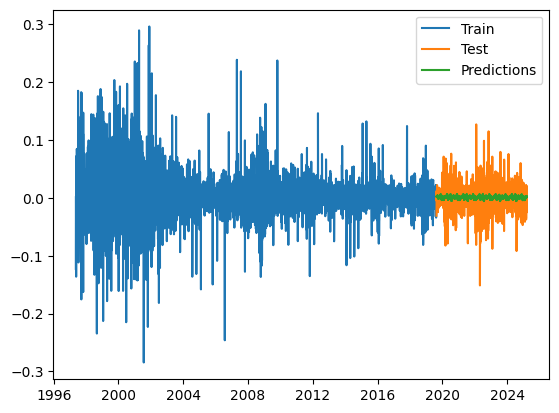

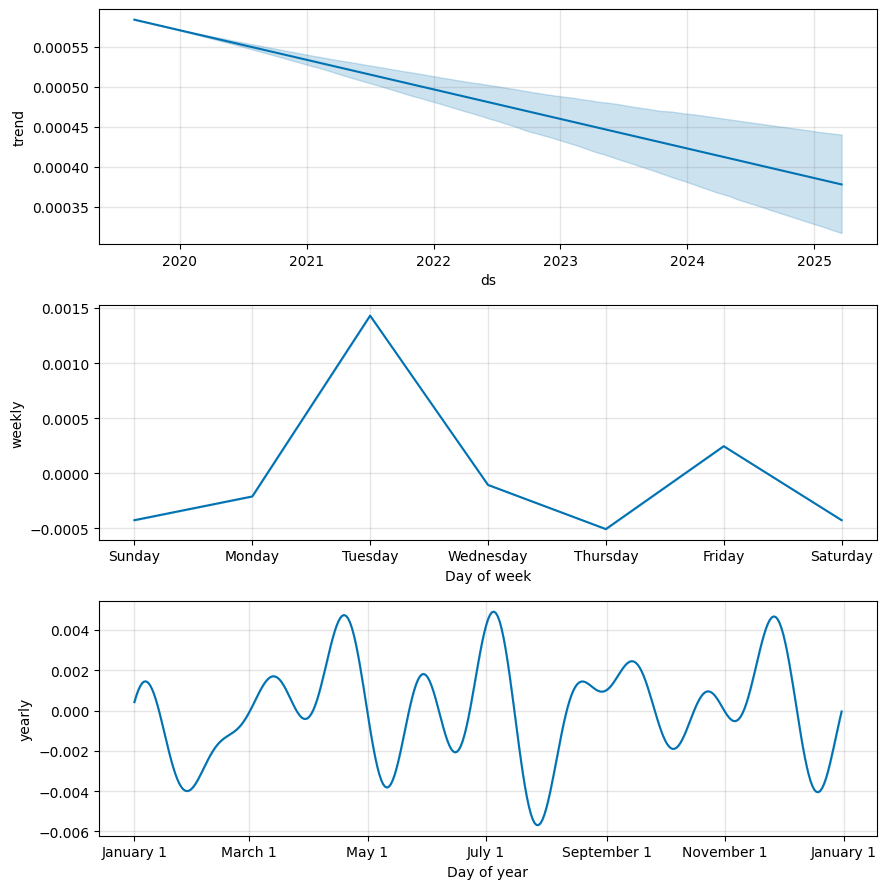

Close


18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing


Valutazione train
ME: 1.7343382138700407e-05, RMSE: 0.03710343166881834, MAE: 0.023534269586970028, MPE: nan, MAPE: inf
Valutazione test
ME: -7.508527321493298e-05, RMSE: 0.0220151656536664, MAE: 0.015863829859127467, MPE: nan, MAPE: inf


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


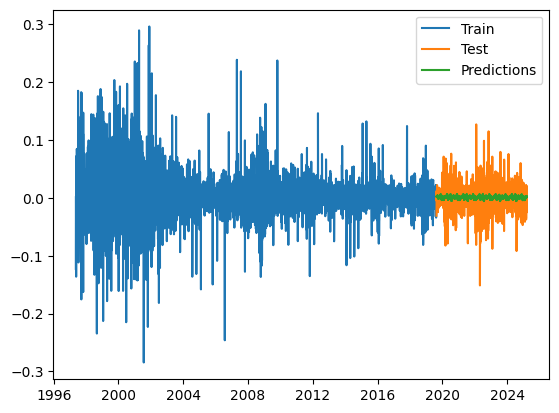

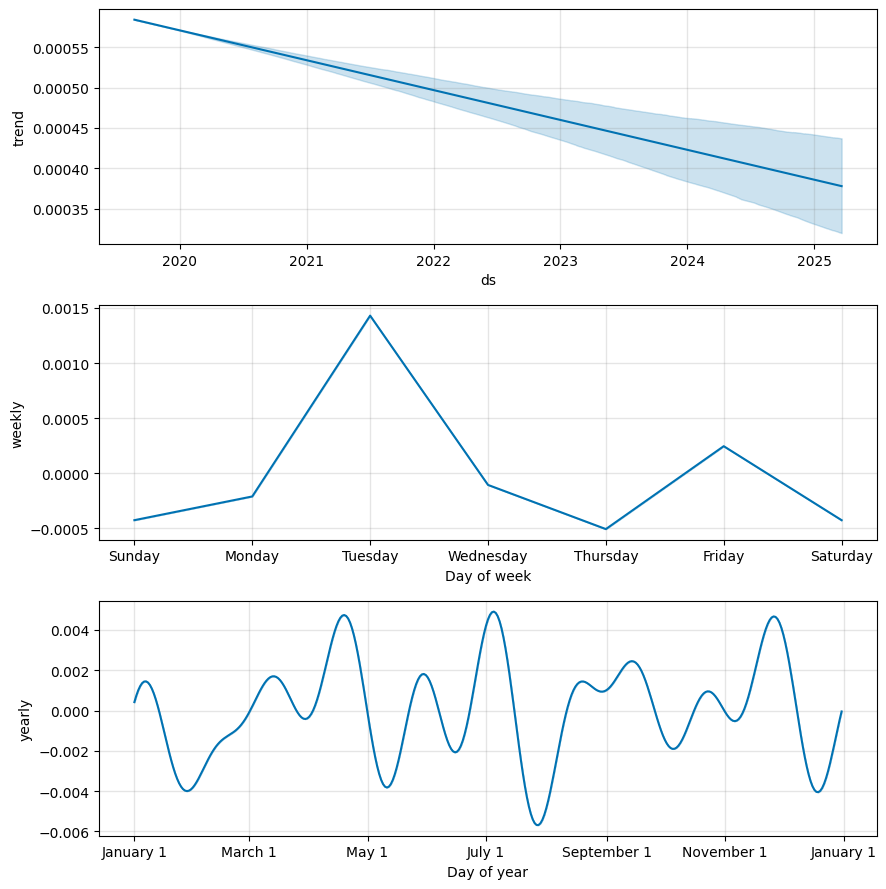

In [25]:
print ('Open')
# Applica il metodo a train_volume e test_volume
model_open = modello_prophet(train_open, test_open)

print ('Close')
# Applica il metodo a train_close e test_close
model_close = modello_prophet(train_close, test_close)

In [26]:
# Metodi con dataset non stazionario
# Preparazione del dataset usato dati log. per problemi di differenza di distribuzione dei dati tra train e test
close_data = df_a_log['Close'].values.reshape(-1, 1)
open_data = df_a_log['Open'].values.reshape(-1, 1)
#divisione train e test
train_a_rnn_close, test_a_rnn_close = train_test_split(close_data, test_size=0.2, shuffle=False)
train_a_rnn_open, test_a_rnn_open = train_test_split(open_data, test_size=0.2, shuffle=False)
print (train_a_rnn_close)

[[-2.32363512]
 [-2.44809656]
 [-2.46021011]
 ...
 [ 4.50057605]
 [ 4.51280269]
 [ 4.50239523]]


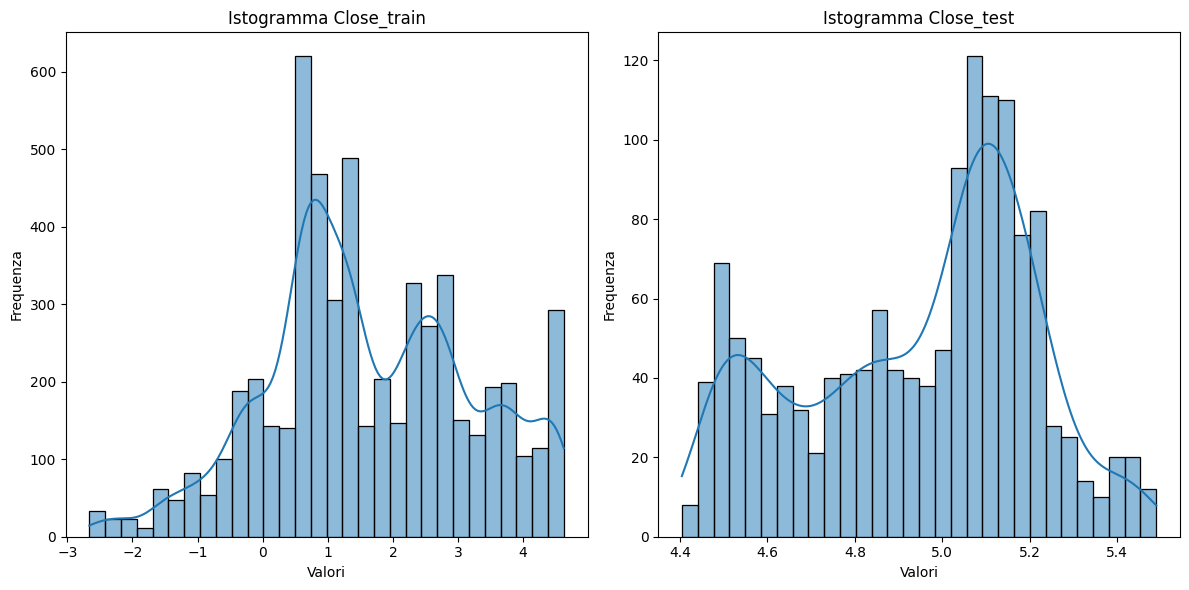

In [27]:
# Crea il istogrammi
# Appiattisci l'array in un array unidimensionale
train_a_rnn_close_flat = train_a_rnn_close.flatten()
df = pd.DataFrame({'valori': train_a_rnn_close_flat})

# Appiattisci l'array in un array unidimensionale
test_a_rnn_close_flat = test_a_rnn_close.flatten()
df_t = pd.DataFrame({'valori': test_a_rnn_close_flat,})


# Crea gli istogrammi
plt.figure(figsize=(12, 6))  # Imposta la dimensione della figura

plt.subplot(1, 2, 1)  # Crea il primo subplot (1 riga, 2 colonne, posizione 1)
sns.histplot(train_a_rnn_close_flat, bins=30, kde=True)
plt.title('Istogramma Close_train')
plt.xlabel('Valori')
plt.ylabel('Frequenza')

plt.subplot(1, 2, 2)  # Crea il secondo subplot (1 riga, 2 colonne, posizione 2)
sns.histplot(test_a_rnn_close_flat, bins=30, kde=True)
plt.title('Istogramma Close_test')
plt.xlabel('Valori')
plt.ylabel('Frequenza')

plt.tight_layout()  # Aggiusta la spaziatura tra i subplot
plt.show()

In [28]:
#RNN
def modello_rnn(train, test, seq_length=10, epochs=100, learning_rate=0.001, dropout_rate=0.3, l2_rate=0.01):
    # 1. Preparazione dei dati
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.reshape(-1, 1)) 
    scaled_test = scaler.transform(test.reshape(-1, 1))

    def create_sequences(data, seq_length):
        xs = []
        ys = []
        for i in range(len(data) - seq_length):
            x = data[i:i+seq_length]
            y = data[i+seq_length]
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(scaled_train, seq_length)
    X_test, y_test = create_sequences(scaled_test, seq_length)

    # 2. Costruzione e addestramento del modello RNN
    model = Sequential()
    model.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(l2_rate)))  # Solo L2 a LSTM
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, kernel_regularizer=l2(l2_rate)))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    # Aggiungi EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # Configura EarlyStopping
    history = model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0) 
    # 3. Effettua le previsioni
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 4. Inverti la scala delle previsioni
    y_train_pred_original = scaler.inverse_transform(y_train_pred)
    y_test_pred_original = scaler.inverse_transform(y_test_pred)
    y_train_original = scaler.inverse_transform(y_train)
    y_test_original = scaler.inverse_transform(y_test)

    # 5. Calcola le metriche di valutazione
    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    mae_train = mean_absolute_error(y_train_original, y_train_pred_original)
    mpe_train = np.mean((y_train_original - y_train_pred_original) / y_train_original) * 100
    mape_train = np.mean(np.abs((y_train_original - y_train_pred_original) / y_train_original)) * 100

    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    mae_test = mean_absolute_error(y_test_original, y_test_pred_original)
    mpe_test = np.mean((y_test_original - y_test_pred_original) / y_test_original) * 100
    mape_test = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100

    # 6. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"ME: {np.mean(y_train_original - y_train_pred_original)}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    print("Valutazione test")
    print(f"ME: {np.mean(y_test_original - y_test_pred_original)}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")

    # 7. Visualizza le previsioni
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(train)), train, label='Train')
    plt.plot(range(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(range(len(train) + seq_length, len(train) + len(test)), y_test_pred_original, label='Predictions') 
    plt.legend()
    plt.show()

    return model, history

CLose


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Valutazione train
ME: 0.01762868825474173, RMSE: 0.18341499533817365, MAE: 0.12938751242247923, MPE: 0.854550981534191, MAPE: 24.750508839933094
Valutazione test
ME: 0.6527537637496714, RMSE: 0.6627422159410504, MAE: 0.6527537637496714, MPE: 13.090796608903139, MAPE: 13.090796608903139


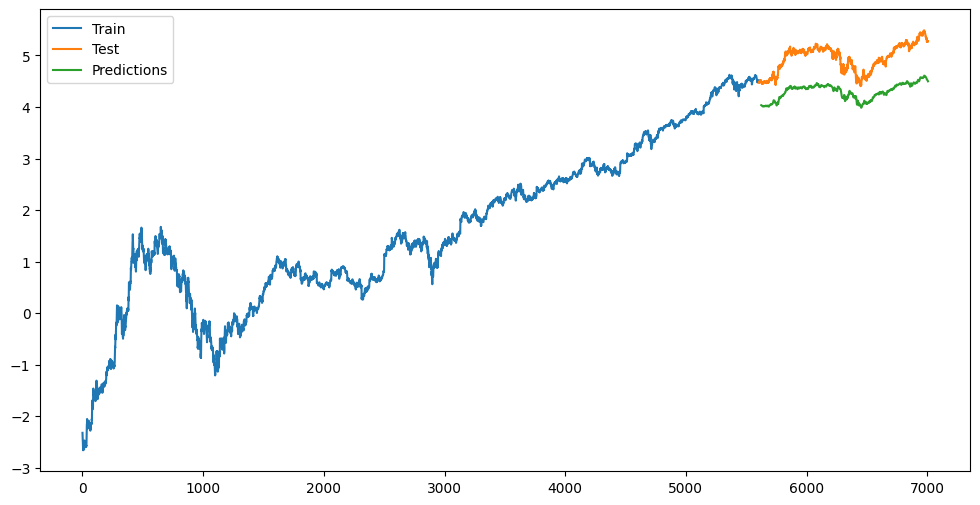

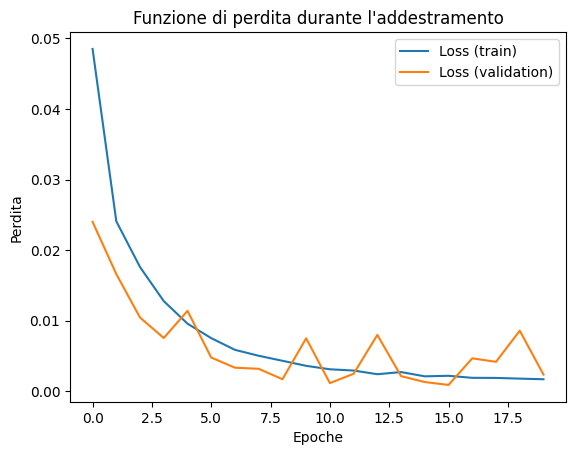

In [29]:
# Esempio di utilizzo per la colonna "Close"
print ('CLose')
model_close, history_close = modello_rnn(train_a_rnn_close, test_a_rnn_close, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_close.history['loss'], label='Loss (train)')
plt.plot(history_close.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()

Open


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Valutazione train
ME: -0.09015127815023224, RMSE: 0.16405857458086798, MAE: 0.11991510308711137, MPE: 10.637477841104145, MAPE: 35.34496668973245
Valutazione test
ME: 0.1054298562544007, RMSE: 0.12587387925412272, MAE: 0.1124935135239341, MPE: 2.0959484017994514, MAPE: 2.2480493899516762


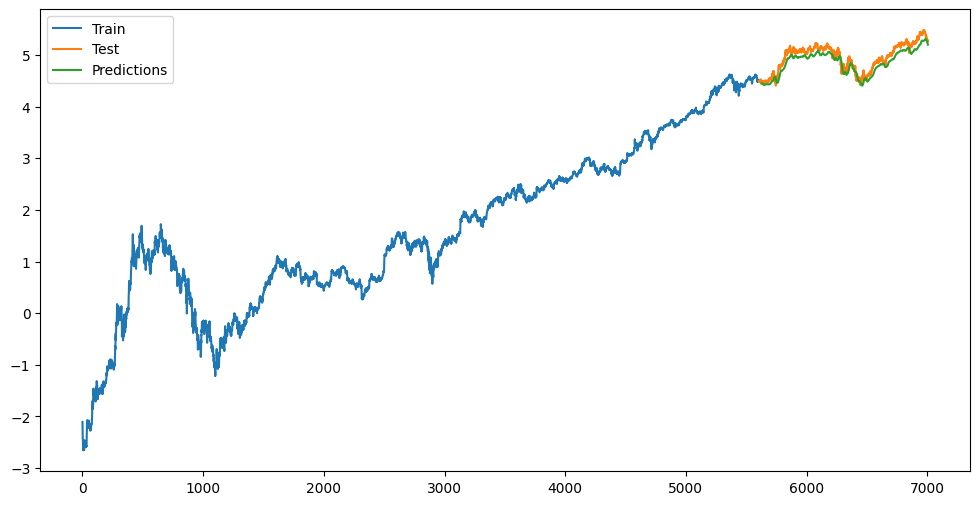

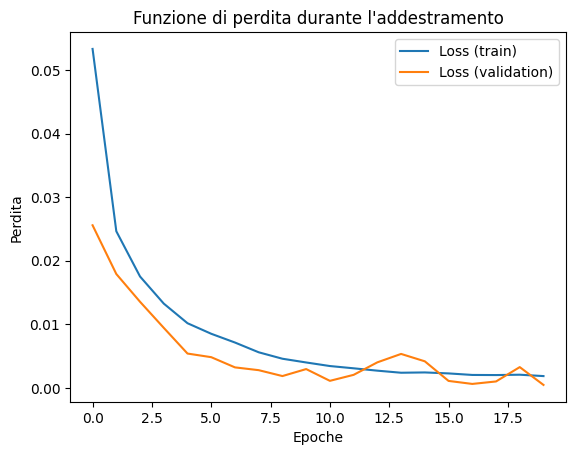

In [30]:
# Esempio di utilizzo per la colonna "Open"
print ('Open')
model_open, history_open = modello_rnn(train_a_rnn_open, test_a_rnn_open, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_open.history['loss'], label='Loss (train)')
plt.plot(history_open.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()

In [31]:
#LSTM
def modello_lstm(train, test, seq_length=10, epochs=100, learning_rate=0.001, dropout_rate=0.2, l2_rate=0.001):
    # 1. Preparazione dei dati
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.reshape(-1, 1))
    scaled_test = scaler.transform(test.reshape(-1, 1))

    def create_sequences(data, seq_length):
        xs = []
        ys = []
        for i in range(len(data) - seq_length):
            x = data[i:i+seq_length]
            y = data[i+seq_length]
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(scaled_train, seq_length)
    X_test, y_test = create_sequences(scaled_test, seq_length)

    # 2. Costruzione e addestramento del modello LSTM con Dropout e L2
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(l2_rate)))  # Utilizza LSTM
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, kernel_regularizer=l2(l2_rate)))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

    # Aggiungi EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0, callbacks=[early_stopping])

    # 3. Effettua le previsioni
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 4. Inverti la scala delle previsioni
    y_train_pred_original = scaler.inverse_transform(y_train_pred)
    y_test_pred_original = scaler.inverse_transform(y_test_pred)
    y_train_original = scaler.inverse_transform(y_train)
    y_test_original = scaler.inverse_transform(y_test)

    # 5. Calcola le metriche di valutazione
    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    mae_train = mean_absolute_error(y_train_original, y_train_pred_original)
    mpe_train = np.mean((y_train_original - y_train_pred_original) / y_train_original) * 100
    mape_train = np.mean(np.abs((y_train_original - y_train_pred_original) / y_train_original)) * 100

    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    mae_test = mean_absolute_error(y_test_original, y_test_pred_original)
    mpe_test = np.mean((y_test_original - y_test_pred_original) / y_test_original) * 100
    mape_test = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100

    # 6. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"ME: {np.mean(y_train_original - y_train_pred_original)}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    print("Valutazione test")
    print(f"ME: {np.mean(y_test_original - y_test_pred_original)}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")

    # 7. Visualizza le previsioni
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(train)), train, label='Train')
    plt.plot(range(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(range(len(train) + seq_length, len(train) + len(test)), y_test_pred_original, label='Predictions')
    plt.legend()
    plt.show()

    return model, history

CLose


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Valutazione train
ME: 0.043530232913311456, RMSE: 0.13390573849989895, MAE: 0.10631731844916265, MPE: -0.64940630369955, MAPE: 21.78489936120697
Valutazione test
ME: -0.34434433176051055, RMSE: 0.3749311216809574, MAE: 0.3443999429011711, MPE: -6.838042915223519, MAPE: 6.839219014012684


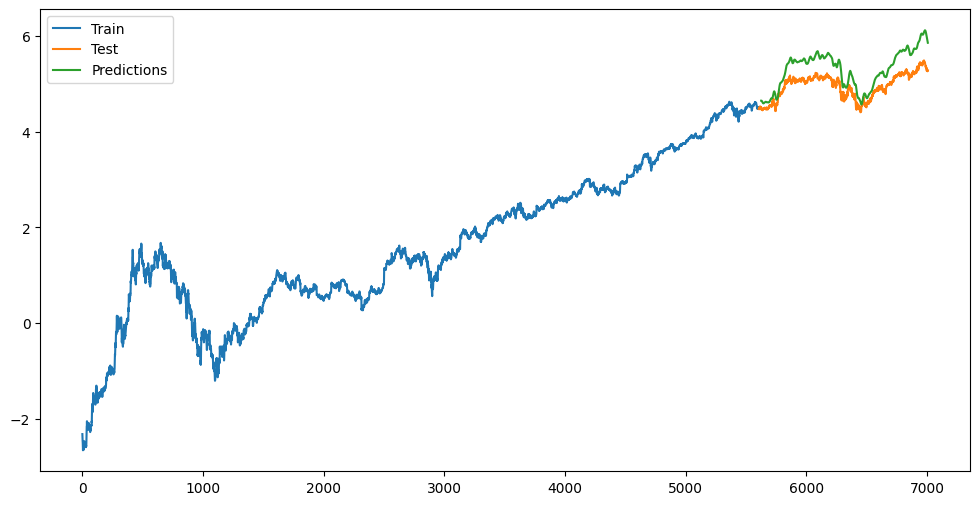

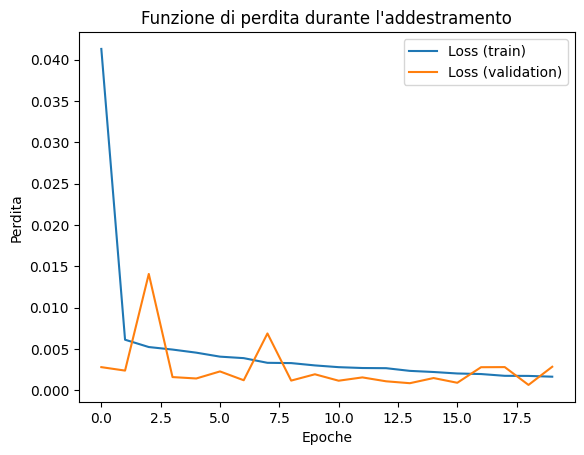

In [32]:
# Esempio di utilizzo per la colonna "Close"
print ('CLose')
model_close, history_close = modello_lstm(train_a_rnn_close, test_a_rnn_close, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_close.history['loss'], label='Loss (train)')
plt.plot(history_close.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()

Open


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Valutazione train
ME: 0.013070545770925573, RMSE: 0.1111416640002629, MAE: 0.0847210518340306, MPE: 6.091006312821184, MAPE: 25.503758715090807
Valutazione test
ME: -0.23803834989177328, RMSE: 0.2752996979709582, MAE: 0.24030703973294196, MPE: -4.699107304049927, MAPE: 4.747613851090878


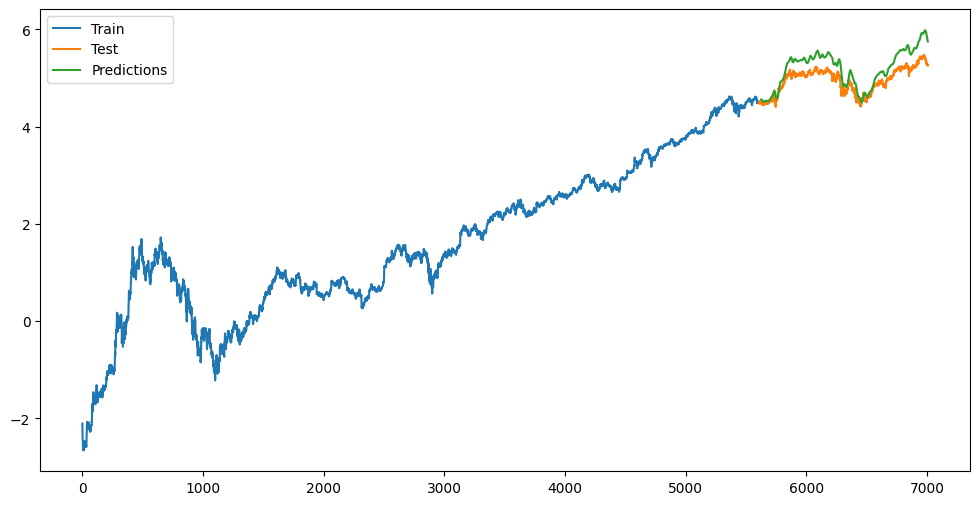

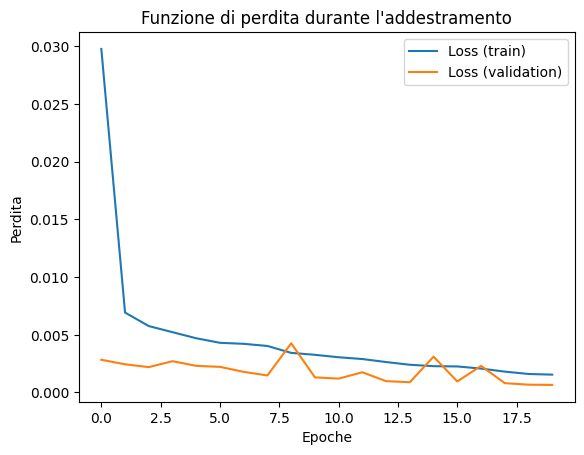

In [33]:
# Esempio di utilizzo per la colonna "Open"
print ('Open')
model_open, history_open = modello_lstm(train_a_rnn_open, test_a_rnn_open, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_open.history['loss'], label='Loss (train)')
plt.plot(history_open.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()